In [46]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os 
import seaborn as sns
def load_kaggle_data(filename, dataset_slug):
    """
    Automatically detects the environment and loads a CSV file 
    using either the local path or the Kaggle server path.
    
    Parameters:
    - filename (str): The name of the file (e.g., 'patients.csv')
    - dataset_slug (str): The dataset folder name used on Kaggle (e.g., 'username/dataset_name')
    """

    kaggle_path = os.path.join('/kaggle/input/datasets/', dataset_slug, filename)
  
    if os.path.exists(kaggle_path):
        print(f"✈️ Running on Kaggle. Loading: {kaggle_path}")
        return pd.read_csv(kaggle_path)
    else:
        print(f"🏠 Running locally. Loading: {filename}")
        return pd.read_csv('../data/'+filename)


In [47]:
heart_data = load_kaggle_data('heart.csv','fedesoriano/heart-failure-prediction')

🏠 Running locally. Loading: heart.csv


In [48]:
heart_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [49]:
heart_data.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [50]:
heart_data.shape

(918, 12)

In [51]:
heart_data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

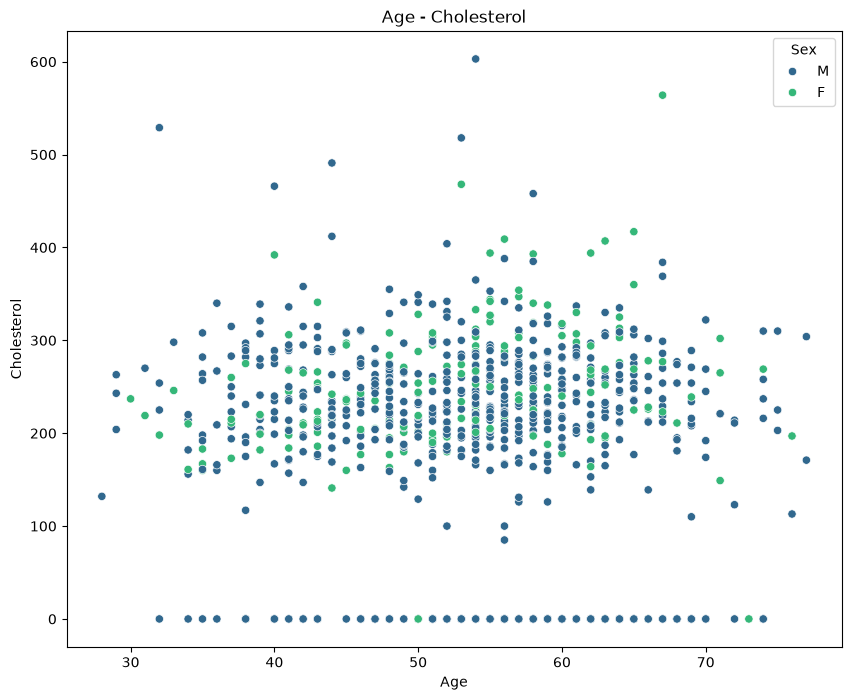

In [52]:
plt.figure(figsize=(10,8))

#plt.scatter(np.arange(0,len(heart_data.Age)),heart_data.Age,c=heart_data.Cholesterol)
#plt.ylabel("Age")
#plt.xlabel("The Index of Age")
plt.title("Age - Cholesterol")
sns.scatterplot(data=heart_data, x='Age', y='Cholesterol',  palette='viridis',hue='Sex')
plt.show()



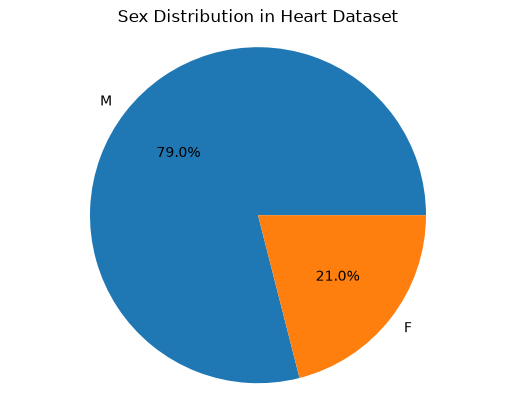

In [53]:
sex_counts = heart_data['Sex'].value_counts()

plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%')
plt.title('Sex Distribution in Heart Dataset')
plt.axis('equal')
plt.show()

In [54]:
heart_data.groupby('ChestPainType')["HeartDisease"].mean().sort_values(ascending=False) * 100

ChestPainType
ASY    79.032258
TA     43.478261
NAP    35.467980
ATA    13.872832
Name: HeartDisease, dtype: float64

In [55]:
heart_data.groupby('RestingECG')["HeartDisease"].mean().sort_values(ascending=False) * 100

RestingECG
ST        65.730337
LVH       56.382979
Normal    51.630435
Name: HeartDisease, dtype: float64

In [56]:
heart_data.groupby('Sex')["HeartDisease"].mean().sort_values(ascending=False) * 100

Sex
M    63.172414
F    25.906736
Name: HeartDisease, dtype: float64

In [57]:
heart_data.groupby('ExerciseAngina')["HeartDisease"].mean().sort_values(ascending=False) * 100

ExerciseAngina
Y    85.175202
N    35.100548
Name: HeartDisease, dtype: float64

In [58]:
heart_data.groupby('ST_Slope')["HeartDisease"].mean().sort_values(ascending=False) * 100

ST_Slope
Flat    82.826087
Down    77.777778
Up      19.746835
Name: HeartDisease, dtype: float64

In [59]:
heart_data = pd.get_dummies(heart_data,dtype=int)

In [60]:
heart_data.columns

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='str')

In [61]:
X = heart_data[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
'ST_Slope_Flat', 'ST_Slope_Up']]

y = heart_data.HeartDisease

In [62]:
from sklearn.model_selection import train_test_split

X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier()

DT.fit(X_train,y_train)

y_pred = DT.predict(X_test)




In [ ]:
from sklearn.metrics import classification_report , accuracy_score

print(classification_report(y_test,y_pred))


              precision    recall  f1-score   support

           0       0.64      0.79      0.71       112
           1       0.83      0.70      0.76       164

    accuracy                           0.74       276
   macro avg       0.73      0.74      0.73       276
weighted avg       0.75      0.74      0.74       276



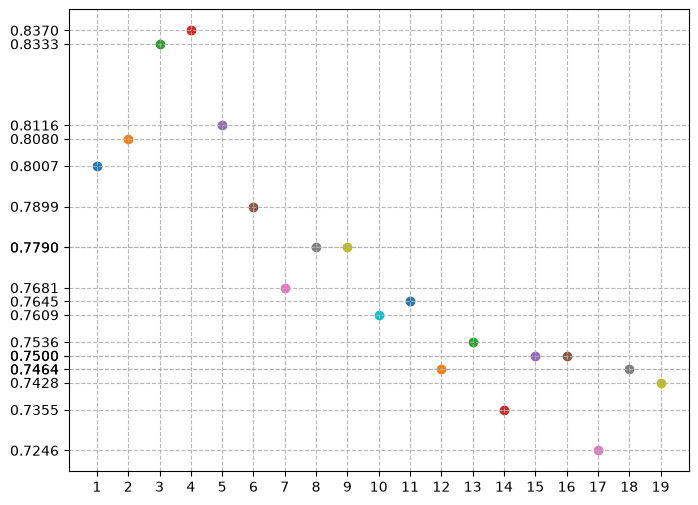

In [88]:
depth_values = np.arange(1,20)
acc_sc = []

for x in depth_values:
    
    DT = DecisionTreeClassifier(max_depth=x)

    DT.fit(X_train,y_train)

    y_pred = DT.predict(X_test)
    
    acc_sc.append(accuracy_score(y_test,y_pred))
    
plt.figure(figsize=(8,6))
for  d,a in zip(depth_values,acc_sc):
    plt.scatter(d,a)
    plt.xticks(depth_values)
    plt.yticks(acc_sc)
    plt.grid(True,linestyle="--",alpha=0.9)
    

    



In [77]:
from sklearn.tree import DecisionTreeClassifier

DT = DecisionTreeClassifier(max_depth=4)

DT.fit(X_train,y_train)

y_pred = DT.predict(X_test)

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       112
           1       0.86      0.87      0.86       164

    accuracy                           0.84       276
   macro avg       0.83      0.83      0.83       276
weighted avg       0.84      0.84      0.84       276

